# YOLOv8 Model Inference Demo

This notebook demonstrates the fundamental inference process of the te camerafishing effort project:

1. Load a trained YOLOv8 model
2. Prepare a test image
3. Run inference using `model.predict()`
4. Display and analyze results

This is the core functionality that our web application automates and makes user-friendly. Instead of running these steps manually, users upload images through the web interface, and the app handles all of this automatically.

## Step 1: Import Required Libraries

We need:
- **ultralytics YOLO**: For loading and running the model
- **OpenCV (cv2)**: For image processing
- **matplotlib**: For visualization
- **NumPy**: For array operations

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Load Model Weights

Load the fine-tuned YOLOv8 model weights from `notebooks/runs/detect/chokepoint_finetuned/train/weights/best.pt`. 

This model was trained on custom boat detection data to detect boats entering and exiting a specific location (chokepoint).

In [2]:
# Define model weights path
model_path = Path("runs/detect/chokepoint_finetuned/train/weights/best.pt")

# Load the model
model = YOLO(str(model_path))

print(f"Model loaded from: {model_path}")

Model loaded from: runs\detect\chokepoint_finetuned\train\weights\best.pt


## Step 3: Load and Prepare Test Image

Load the test image from `notebooks/img/IM_03513.JPG` and display it to see what we're working with.

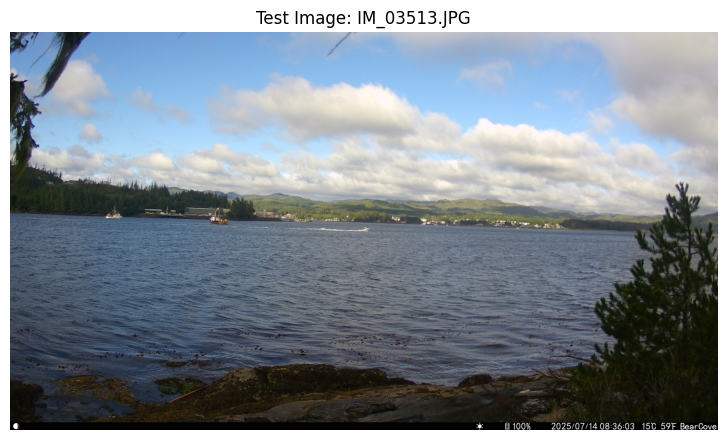

In [3]:
image_path = Path("img/IM_03513.JPG")

# Load the image using OpenCV (BGR format)
image_bgr = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(8, 4.5))
plt.imshow(image_rgb)
plt.title(f"Test Image: {image_path.name}")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 4: Run Model Inference

Now we run the model inference using `model.predict()`. This is the **core step** that processes the image and detects boats:
- Extracts features from the image
- Runs them through the neural network
- Returns bounding boxes, class labels, and confidence scores

In [4]:
# Run inference on the test image
results = model.predict(source=str(image_path), conf=0.5)
result = results[0]

print("Inference completed successfully!")
print(f"Detections found: {len(result.boxes)}")


image 1/1 c:\Users\hp\Desktop\PSF\camera_fishing_effort\notebooks\img\IM_03513.JPG: 256x416 2 ins, 133.7ms
Speed: 2.1ms preprocess, 133.7ms inference, 5.2ms postprocess per image at shape (1, 3, 256, 416)
Inference completed successfully!
Detections found: 2


## Step 5: Display Prediction Results

Visualize the detections by drawing bounding boxes on the image with class labels and confidence scores.

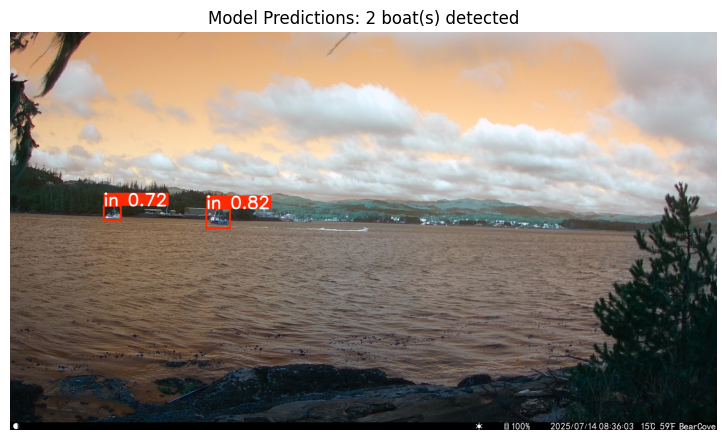

In [5]:
# Get annotated image with bounding boxes
annotated_image = result.plot()  # Returns RGB image with boxes drawn

# Display the annotated image
plt.figure(figsize=(8, 4.5))
plt.imshow(annotated_image)
plt.title(f"Model Predictions: {len(result.boxes)} boat(s) detected")
plt.axis("off")
plt.tight_layout()
plt.show()

The model has detected 2 boats going "in" with a confidence of 72% and 82% respectively.